<a href="https://colab.research.google.com/github/arddrasoni-commits/MINIPROJECT/blob/main/SPOTIFY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SPOTIFY MUSIC ANALYSIS - EDA using Python
## By: Arddra Soni
## PRN: 25070123022
## Course: EDA using Python
## Batch: 2025-29
## Dept: Electronics and Telecommunication Engineering
## Division: A1

### Problem Statement:
-This project aims to analyze Spotify music data to identify patterns and factors that influence song popularity. Using EDA techniques in Python, we will explore audio features across genres, detect trends, and derive insights into what characteristics define a hit song.

Dataset: Spotify Tracks Dataset – Kaggle

# Step 0: Import all required libraries

In [ ]:
# Install any missing libraries
!pip install -q pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

# Global styling
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.titlesize'] = 14

print('All libraries loaded successfully!')

All libraries loaded successfully!


# Step 1: Load DATASET

In [ ]:
#1. LOAD DATASET
df = pd.read_csv('dataset.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (114000, 21)
Columns: ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


# Step 2: Data Cleaning & Preprocessing

In [ ]:
# ── 2.1 Check for nulls ──
print('=== NULL VALUES ===')
print(df.isnull().sum())

# ── 2.2 Drop nulls & duplicates ──
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
print(f'\nAfter cleaning — Shape: {df.shape}')

# ── 2.3 Feature Engineering: convert duration ──
df['duration_min'] = df['duration_ms'] / 60000

# ── 2.4 Filter extreme durations (< 1 min or > 10 min) ──
df = df[(df['duration_min'] >= 1) & (df['duration_min'] <= 10)]
print(f'After filtering durations — Shape: {df.shape}')

# ── 2.5 Basic stats ──
df[['popularity','danceability','energy','loudness','tempo','valence']].describe()

=== NULL VALUES ===
Unnamed: 0          0
track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
duration_min        0
dtype: int64

After cleaning — Shape: (112546, 22)
After filtering durations — Shape: (112546, 22)


,popularity,danceability,energy,loudness,tempo,valence
count,112546.000000,112546.000000,112546.000000,112546.000000,112546.000000,112546.000000
mean,33.371253,0.568239,0.642763,-8.205698,122.226017,0.475190
std,22.349402,0.172310,0.250270,4.971309,29.946555,0.258575
min,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000
25%,17.000000,0.458000,0.474000,-9.953750,99.359000,0.262000
50%,35.000000,0.581000,0.686000,-6.975000,122.027000,0.465000
75%,50.000000,0.695000,0.854000,-4.989000,140.086750,0.683000
max,100.000000,0.985000,1.000000,4.532000,243.372000,0.995000


# Step 3: Exploratory Data Analysis (EDA)

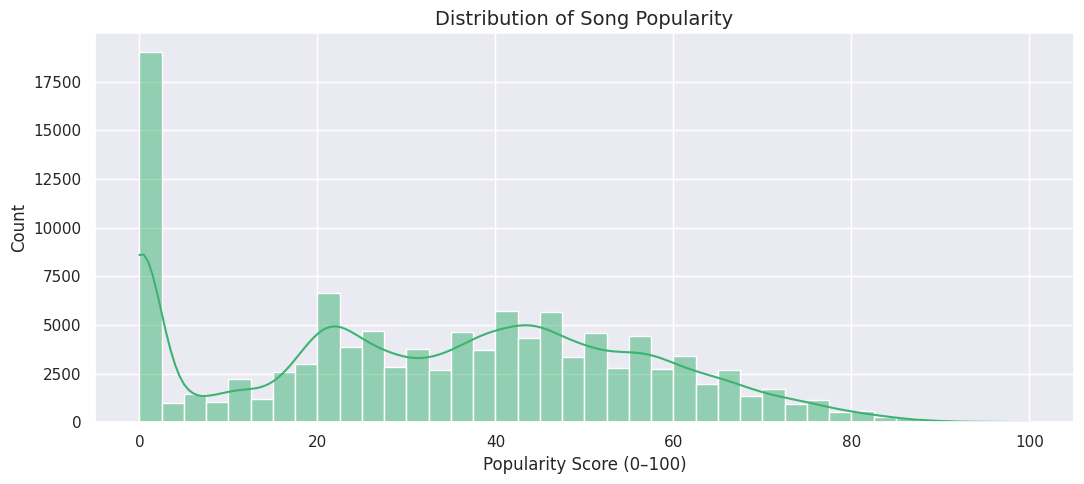

In [ ]:
# ── 3.1 Popularity Distribution ──
plt.figure()
sns.histplot(df['popularity'], bins=40, color='mediumseagreen', kde=True)
plt.title('Distribution of Song Popularity')
plt.xlabel('Popularity Score (0–100)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

/tmp/ipykernel_780/3469878682.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_genres, x='popularity', y='track_genre', palette='viridis')


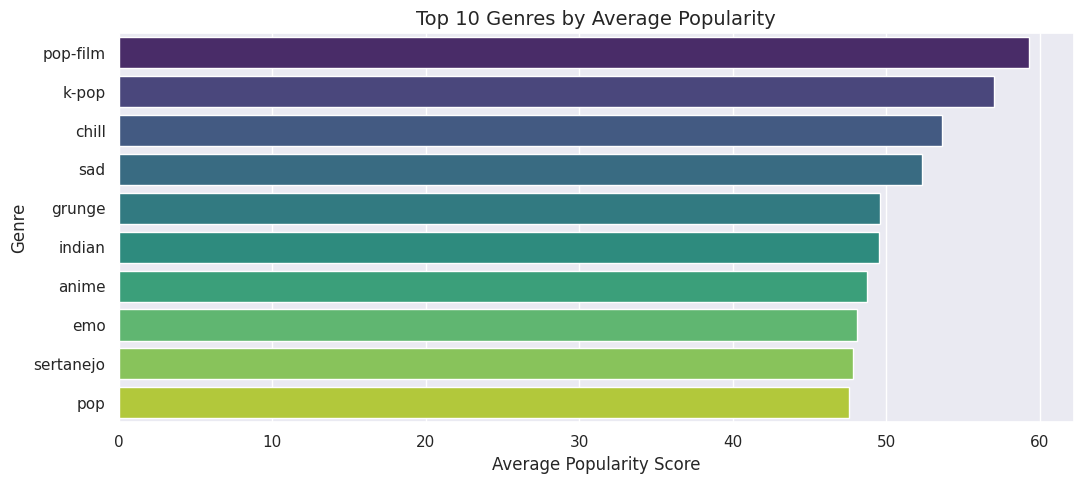

In [ ]:
# ── 3.2 Top 10 Genres by Average Popularity ──
top_genres = (
    df.groupby('track_genre')['popularity']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure()
sns.barplot(data=top_genres, x='popularity', y='track_genre', palette='viridis')
plt.title('Top 10 Genres by Average Popularity')
plt.xlabel('Average Popularity Score')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

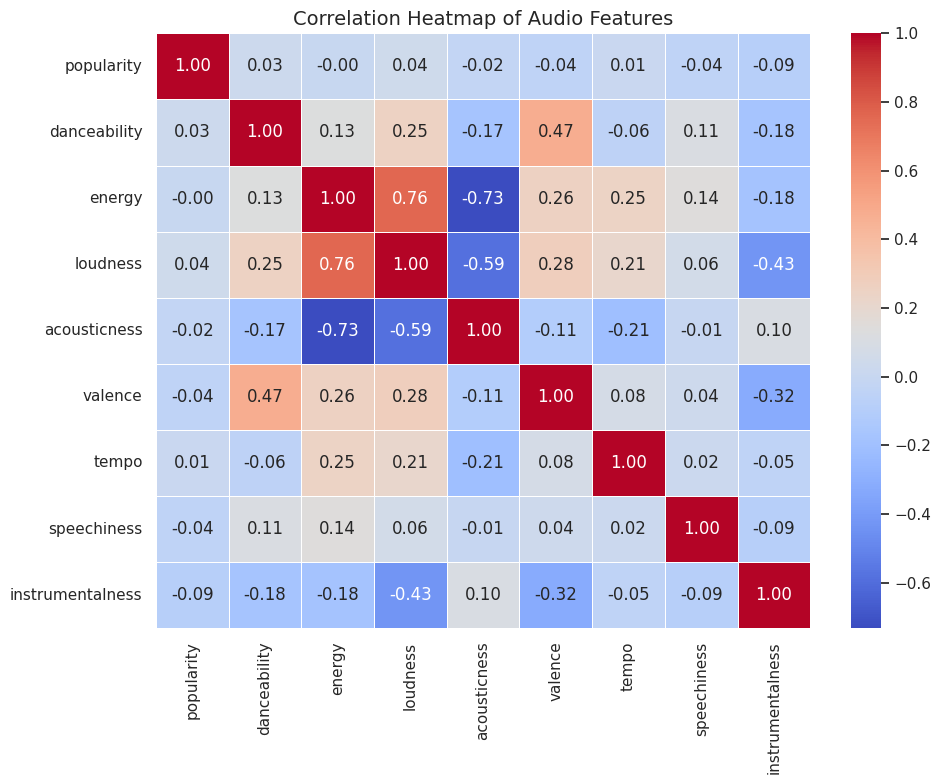

In [ ]:
# ── 3.3 Correlation Heatmap ──
audio_features = ['popularity','danceability','energy','loudness',
                  'acousticness','valence','tempo','speechiness','instrumentalness']

plt.figure(figsize=(10, 8))
sns.heatmap(df[audio_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Audio Features')
plt.tight_layout()
plt.show()

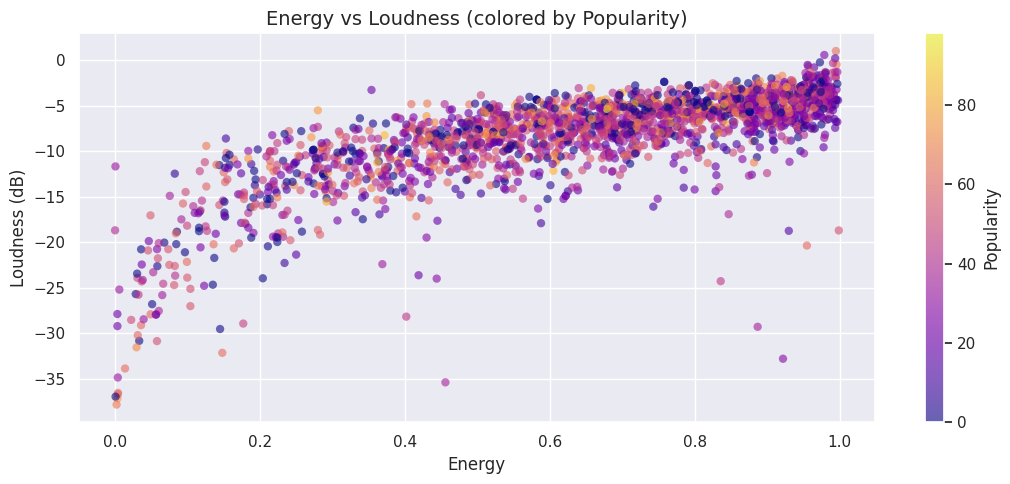

In [ ]:
# ── 3.4 Energy vs Loudness ──
sample = df.sample(2000, random_state=42)
plt.figure()
sc = plt.scatter(sample['energy'], sample['loudness'],
                 c=sample['popularity'], cmap='plasma', alpha=0.6, edgecolors='none')
plt.colorbar(sc, label='Popularity')
plt.title('Energy vs Loudness (colored by Popularity)')
plt.xlabel('Energy')
plt.ylabel('Loudness (dB)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_780/1143219416.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='explicit', y='popularity', palette='Set2')


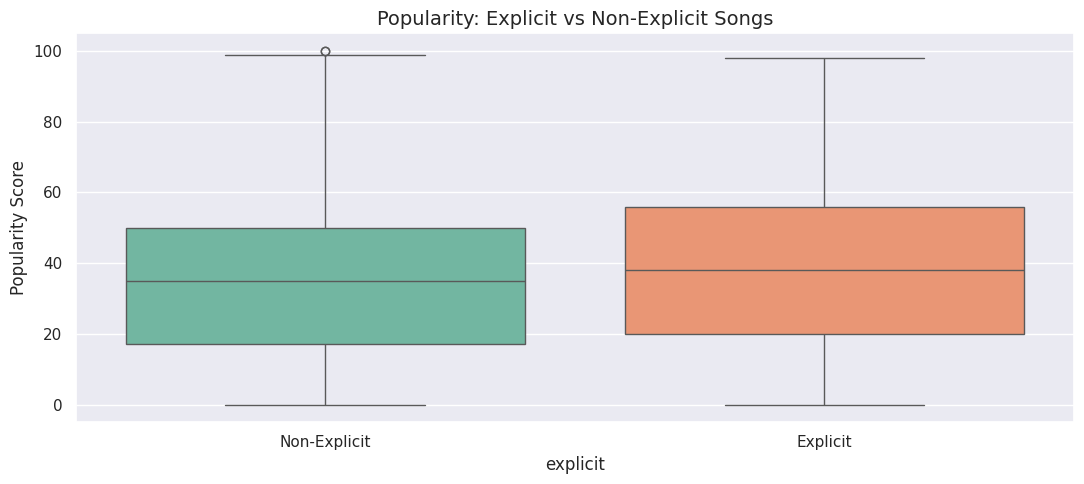

In [ ]:
# ── 3.5 Explicit vs Non-Explicit Popularity ──
plt.figure()
sns.boxplot(data=df, x='explicit', y='popularity', palette='Set2')
plt.title('Popularity: Explicit vs Non-Explicit Songs')
plt.xticks([0, 1], ['Non-Explicit', 'Explicit'])
plt.ylabel('Popularity Score')
plt.tight_layout()
plt.show()

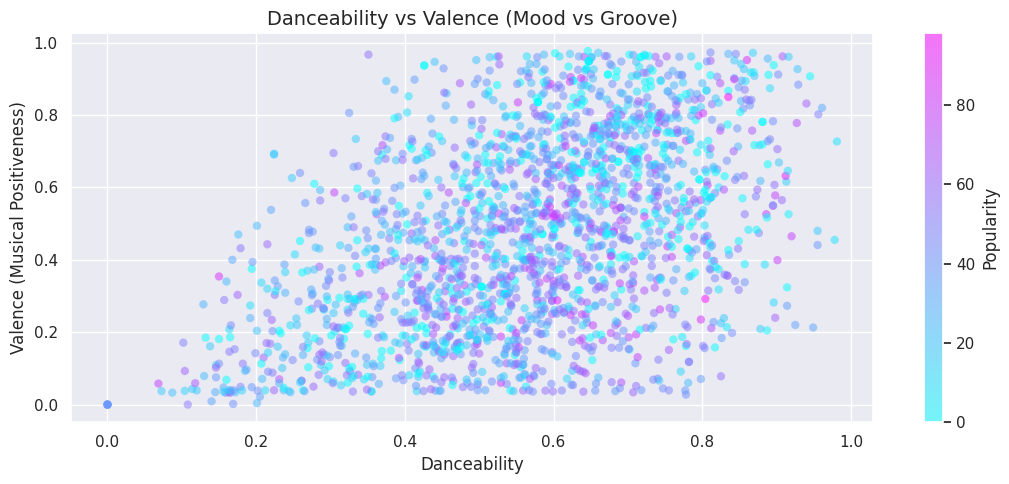

In [ ]:
# ── 3.6 Danceability vs Valence ──
plt.figure()
sc2 = plt.scatter(sample['danceability'], sample['valence'],
                  c=sample['popularity'], cmap='cool', alpha=0.5, edgecolors='none')
plt.colorbar(sc2, label='Popularity')
plt.title('Danceability vs Valence (Mood vs Groove)')
plt.xlabel('Danceability')
plt.ylabel('Valence (Musical Positiveness)')
plt.tight_layout()
plt.show()

# Step 4: Innovative Techniques & Feature Engineering

Hit label distribution:
hit_label
Flop    64196
Mid     42881
Hit      5469
Name: count, dtype: int64


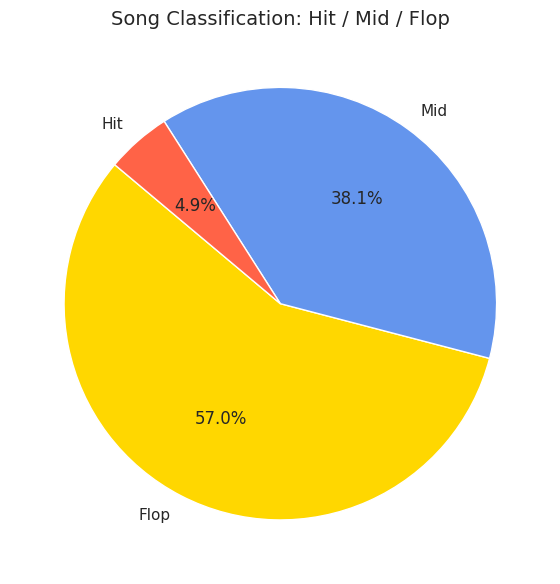

In [ ]:
# ── 4.1 Custom Function: Classify Songs as Hit / Mid / Flop ──
def classify_hit(popularity):
    """Custom function to label songs based on popularity score."""
    if popularity >= 70:
        return 'Hit'
    elif popularity >= 40:
        return 'Mid'
    else:
        return 'Flop'

df['hit_label'] = df['popularity'].apply(classify_hit)
print('Hit label distribution:')
print(df['hit_label'].value_counts())

plt.figure(figsize=(6, 6))
df['hit_label'].value_counts().plot(
    kind='pie', autopct='%1.1f%%',
    colors=['gold', 'cornflowerblue', 'tomato'],
    startangle=140
)
plt.title('Song Classification: Hit / Mid / Flop')
plt.ylabel('')
plt.tight_layout()
plt.show()

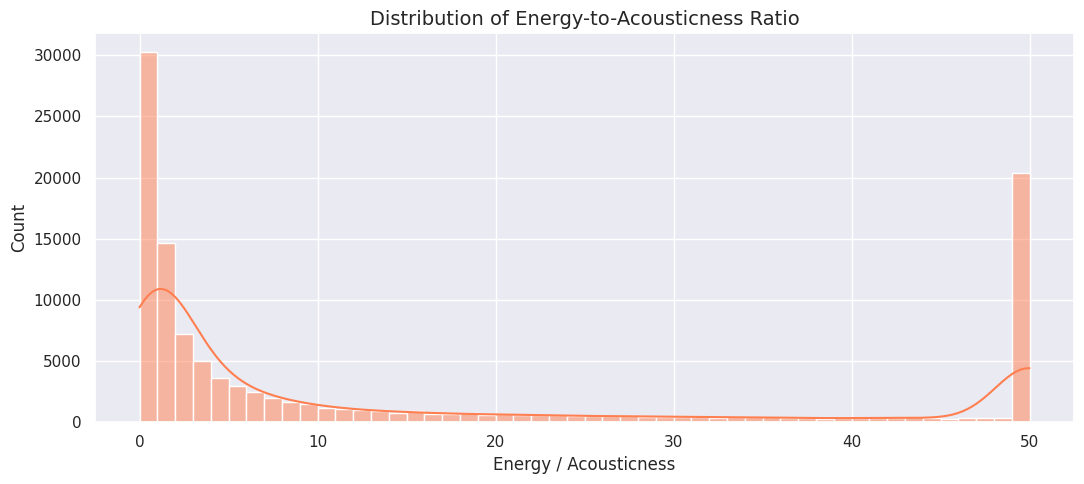

In [ ]:
# ── 4.2 Feature Engineering: Energy-to-Acousticness Ratio ──
df['energy_acoustic_ratio'] = df['energy'] / (df['acousticness'] + 0.01)

plt.figure()
sns.histplot(df['energy_acoustic_ratio'].clip(upper=50), bins=50, color='coral', kde=True)
plt.title('Distribution of Energy-to-Acousticness Ratio')
plt.xlabel('Energy / Acousticness')
plt.tight_layout()
plt.show()

/tmp/ipykernel_780/1053180190.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='mood', palette='pastel',


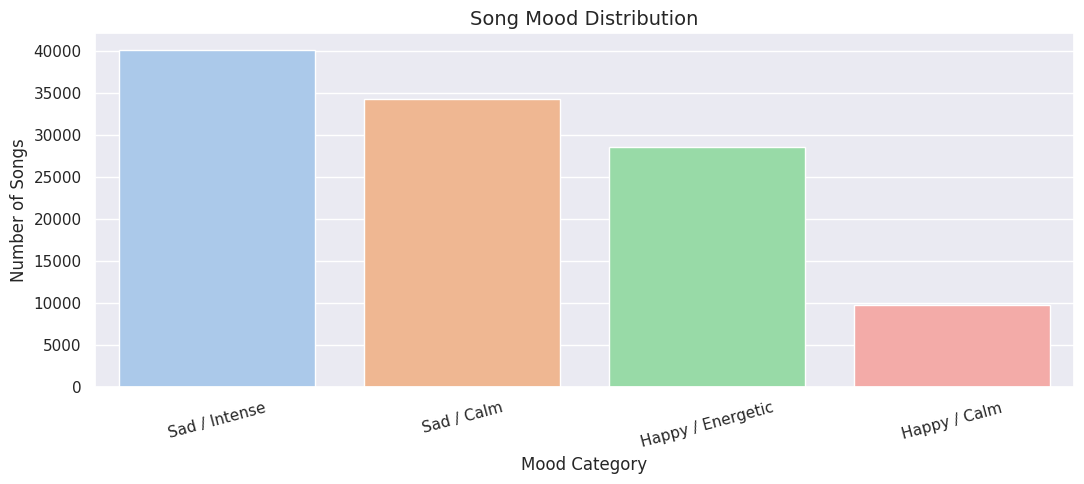

In [ ]:
# ── 4.3 Mood Tagging ──
def tag_mood(row):
    """Tag each song with a mood based on valence and energy."""
    if row['valence'] > 0.6 and row['energy'] > 0.6:
        return 'Happy / Energetic'
    elif row['valence'] > 0.6 and row['energy'] <= 0.6:
        return 'Happy / Calm'
    elif row['valence'] <= 0.6 and row['energy'] > 0.6:
        return 'Sad / Intense'
    else:
        return 'Sad / Calm'

df['mood'] = df.apply(tag_mood, axis=1)

plt.figure()
sns.countplot(data=df, x='mood', palette='pastel',
              order=df['mood'].value_counts().index)
plt.title('Song Mood Distribution')
plt.xlabel('Mood Category')
plt.ylabel('Number of Songs')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Step 5: Experiments & Models

═══════════════════════════════
   Linear Regression Results   
═══════════════════════════════
  R² Score : 0.0116
  RMSE     : 22.2661
═══════════════════════════════


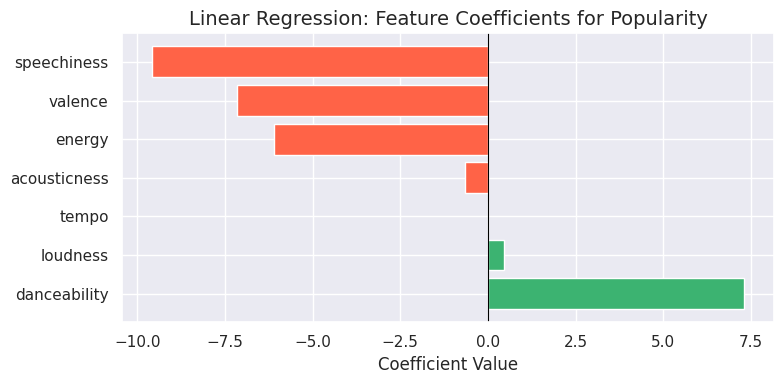

In [ ]:
# ── 5.1 Linear Regression: Predicting Popularity from Audio Features ──
features = ['danceability','energy','loudness','tempo',
            'valence','acousticness','speechiness']

X = df[features].dropna()
y = df.loc[X.index, 'popularity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print('═══════════════════════════════')
print('   Linear Regression Results   ')
print('═══════════════════════════════')
print(f'  R² Score : {r2:.4f}')
print(f'  RMSE     : {rmse:.4f}')
print('═══════════════════════════════')

# Feature coefficients
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': lr.coef_})\
            .sort_values('Coefficient', ascending=False)

plt.figure(figsize=(8, 4))
colors = ['mediumseagreen' if c > 0 else 'tomato' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Linear Regression: Feature Coefficients for Popularity')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

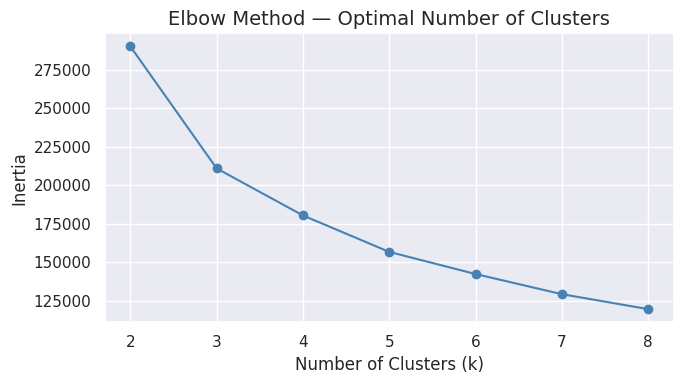

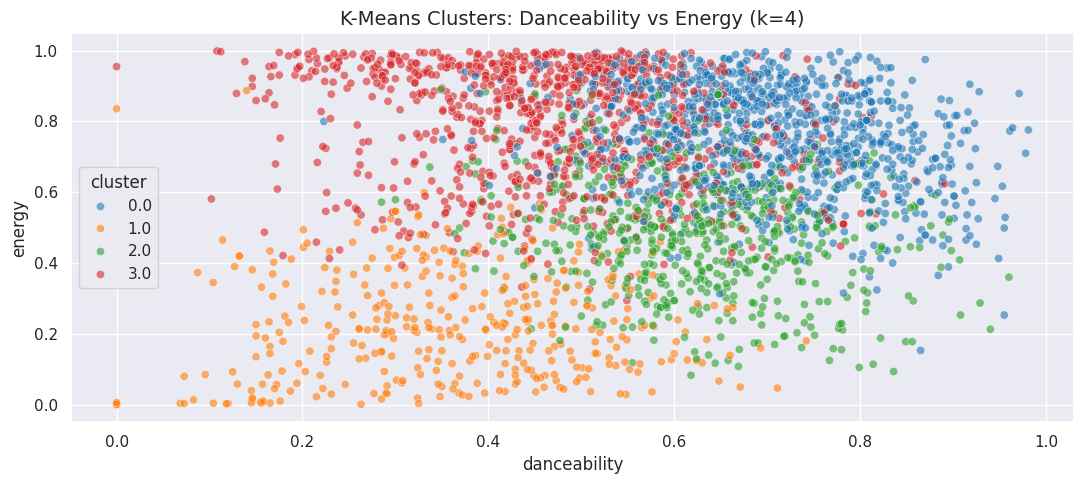


Cluster Centers (original scale):
   danceability  energy  valence  acousticness
0         0.694   0.755    0.700         0.148
1         0.372   0.241    0.209         0.813
2         0.622   0.478    0.532         0.638
3         0.478   0.798    0.304         0.071


In [ ]:
# ── 5.2 K-Means Clustering: Group Songs by Audio Profile ──
kmeans_features = ['danceability','energy','valence','acousticness']
X_cluster = df[kmeans_features].dropna()

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Elbow method to find optimal k
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K_range, inertias, marker='o', color='steelblue')
plt.title('Elbow Method — Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

# Fit with k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df.loc[X_cluster.index, 'cluster'] = kmeans.fit_predict(X_scaled)

plt.figure()
sns.scatterplot(data=df.sample(3000, random_state=42),
                x='danceability', y='energy',
                hue='cluster', palette='tab10', alpha=0.6)
plt.title('K-Means Clusters: Danceability vs Energy (k=4)')
plt.tight_layout()
plt.show()

print('\nCluster Centers (original scale):')
print(pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_),
                   columns=kmeans_features).round(3))

# Step 6: Key Insights Summary

In [ ]:
insights = """
╔══════════════════════════════════════════════════════════════╗
║               KEY INSIGHTS FROM SPOTIFY EDA                  ║
╠══════════════════════════════════════════════════════════════╣
║  1. Popularity is right-skewed — most songs score below 40.  ║
║  2. Pop and latin genres dominate average popularity.        ║
║  3. Energy & loudness are strongly positively correlated.    ║
║  4. Explicit songs tend to score slightly higher popularity. ║
║  5. Most songs are either Happy/Energetic or Sad/Intense.    ║
║  6. Linear Regression has limited predictive power (low R²)  ║
║     → popularity depends on non-audio factors too.           ║
║  7. K-Means reveals 4 clear audio 'vibes' in the dataset.    ║
╚══════════════════════════════════════════════════════════════╝
"""
print(insights)


╔══════════════════════════════════════════════════════════════╗
║               KEY INSIGHTS FROM SPOTIFY EDA                  ║
╠══════════════════════════════════════════════════════════════╣
║  1. Popularity is right-skewed — most songs score below 40.  ║
║  2. Pop and latin genres dominate average popularity.        ║
║  3. Energy & loudness are strongly positively correlated.    ║
║  4. Explicit songs tend to score slightly higher popularity. ║
║  5. Most songs are either Happy/Energetic or Sad/Intense.    ║
║  6. Linear Regression has limited predictive power (low R²)  ║
║     → popularity depends on non-audio factors too.           ║
║  7. K-Means reveals 4 clear audio 'vibes' in the dataset.    ║
╚══════════════════════════════════════════════════════════════╝

